# 04 · Kupon stratejisi ve maliyet-getiri simülasyonu

Fırsat puanı **nereye** odaklanacağımızı söylüyor. Bu notebook **ne kadar indirim**, **kime** ve **kendini ne zaman amorti eder**
sorularını cevaplıyor.

> ⚠️ **Önemli:** Elimizde bir paylaşımlı ulaşım şirketinin gerçek verisi yok. Aşağıdaki hesap **açıkça yazılmış varsayımlara**
> dayanan bir senaryo modelidir. Amaç kesin bir rakam vermek değil, **hangi stratejinin hangi koşulda kârlı olduğunu** göstermek.
> Varsayımlar tek bir hücrede toplandı; değiştirip notebook'u tekrar çalıştırarak farklı senaryoları deneyebilirsiniz.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30, "display.width", 160)

from db import baglan, sorgu
from gorsel import *
stil_uygula()

import numpy as np
from utils import PROCESSED
puan = pd.read_csv(PROCESSED / "firsat_puanlari.csv")

## 1. Varsayımlar

In [2]:
VARSAYIM = {
    # Pazar
    "baz_pay": 0.005,          # Zirve saat toplu taşıma yolculuklarının %0,5'i kadar paylaşımlı yolculuk zaten var
    "is_gunu_ay": 22,
    # Fiyat ve marj (2024 İstanbul için kaba ortalamalar)
    "ucret": {"Scooter / e-bisiklet": 70, "Paylaşımlı araç / mikro-servis": 180},   # TL / yolculuk
    "marj":  {"Scooter / e-bisiklet": 0.30, "Paylaşımlı araç / mikro-servis": 0.20}, # katkı marjı
    # Talep tepkisi: %1 indirim talebi kaç % artırır? (fiyat esnekliği, mutlak değer)
    "esneklik": {"kötümser": 0.6, "orta": 1.2, "iyimser": 2.0},
    # Kampanya bittikten sonra yeni yolculukların ne kadarı kalıcı olur?
    "kalicilik": {"kötümser": 0.10, "orta": 0.20, "iyimser": 0.35},
    # Hedefli kuponda, zaten kullanan müşterilerin de kupon alma oranı (sızıntı)
    "sizinti": 0.15,
}
HEDEF_ILCE_SAYISI = 5

## 2. Hedef ilçeler
Fırsat puanında ilk sıralarda olan ve "düşük öncelik" olmayan 5 ilçe:

In [3]:
hedef = puan[puan["oneri"] != "Düşük öncelik"].head(HEDEF_ILCE_SAYISI).copy()
hedef["baz_yolculuk_gun"] = hedef["zirve_binis"] * VARSAYIM["baz_pay"]
hedef["ucret"] = hedef["oneri"].map(VARSAYIM["ucret"])
hedef["marj"] = hedef["oneri"].map(VARSAYIM["marj"])
hedef[["ad", "firsat_puani", "oneri", "zirve_binis", "baz_yolculuk_gun", "ucret", "marj"]].round(1)

,ad,firsat_puani,oneri,zirve_binis,baz_yolculuk_gun,ucret,marj
0,Sultanbeyli,78.7,Paylaşımlı araç / mikro-servis,39545.0,197.7,180,0.2
1,Sancaktepe,77.9,Paylaşımlı araç / mikro-servis,68284.0,341.4,180,0.2
2,Küçükçekmece,68.1,Scooter / e-bisiklet,123398.0,617.0,70,0.3
3,Esenyurt,66.4,Scooter / e-bisiklet,81477.0,407.4,70,0.3
4,Sultangazi,65.1,Scooter / e-bisiklet,59855.0,299.3,70,0.3


## 3. Model

Bir ay süren, sadece zirve saatlerde geçerli **d** oranında indirim kampanyası için:

- **Yeni yolculuk** = baz yolculuk × esneklik × d
- **Kampanya kazancı** = yeni yolculuk × ücret × marj
- **Kupon maliyeti**
  - *Herkese kupon:* d × ücret × (baz + yeni). Zaten kullananlara da indirim verilir → **yamyamlaşma**
  - *Hedefli kupon (yeni kullanıcıya):* d × ücret × (yeni + baz × sızıntı)
- **Kampanya sonrası** her ay: yeni yolculuk × kalıcılık × ücret × marj

In [4]:
def simule(d: float, senaryo: str, hedefli: bool, ay: int = 12) -> pd.DataFrame:
    e, k = VARSAYIM["esneklik"][senaryo], VARSAYIM["kalicilik"][senaryo]
    g = VARSAYIM["is_gunu_ay"]
    baz = hedef["baz_yolculuk_gun"] * g
    yeni = baz * e * d
    kazanc = (yeni * hedef["ucret"] * hedef["marj"]).sum()
    kuponlu = yeni + baz * (VARSAYIM["sizinti"] if hedefli else 1.0)
    maliyet = (kuponlu * hedef["ucret"] * d).sum()
    sonrasi = (yeni * k * hedef["ucret"] * hedef["marj"]).sum()
    net = [kazanc - maliyet] + [sonrasi] * (ay - 1)
    return pd.DataFrame({"ay": range(1, ay + 1), "net": net, "kumulatif": np.cumsum(net),
                         "yeni_yolculuk_ay1": yeni.sum(), "maliyet_ay1": maliyet})

satirlar = []
for d in [0.10, 0.20, 0.30]:
    for senaryo in VARSAYIM["esneklik"]:
        for hedefli in [False, True]:
            s = simule(d, senaryo, hedefli)
            amorti = s.loc[s["kumulatif"] >= 0, "ay"]
            satirlar.append({
                "indirim": f"%{d*100:.0f}", "senaryo": senaryo,
                "strateji": "Hedefli" if hedefli else "Herkese",
                "ek_yolculuk_ay1": round(s["yeni_yolculuk_ay1"].iloc[0]),
                "kupon_maliyeti_bin_tl": round(s["maliyet_ay1"].iloc[0] / 1000),
                "ay1_net_bin_tl": round(s["net"].iloc[0] / 1000),
                "12ay_kumulatif_bin_tl": round(s["kumulatif"].iloc[-1] / 1000),
                "amorti_ayi": int(amorti.iloc[0]) if len(amorti) else None,
            })
ozet = pd.DataFrame(satirlar)
ozet

,indirim,senaryo,strateji,ek_yolculuk_ay1,kupon_maliyeti_bin_tl,ay1_net_bin_tl,12ay_kumulatif_bin_tl,amorti_ayi
0,%10,kötümser,Herkese,2459,442,-380,-312,NaN
1,%10,kötümser,Hedefli,2459,88,-25,43,6.0
2,%10,orta,Herkese,4918,467,-343,-69,NaN
3,%10,orta,Hedefli,4918,113,12,286,1.0
4,%10,iyimser,Herkese,8196,501,-293,507,6.0
5,%10,iyimser,Hedefli,8196,146,62,861,1.0
6,%20,kötümser,Herkese,4918,935,-810,-673,NaN
7,%20,kötümser,Hedefli,4918,225,-101,36,10.0
8,%20,orta,Herkese,9836,1035,-786,-237,NaN
9,%20,orta,Hedefli,9836,326,-76,472,3.0


## 4. Hedefli ve herkese kupon karşılaştırması (orta senaryo, %20 indirim)

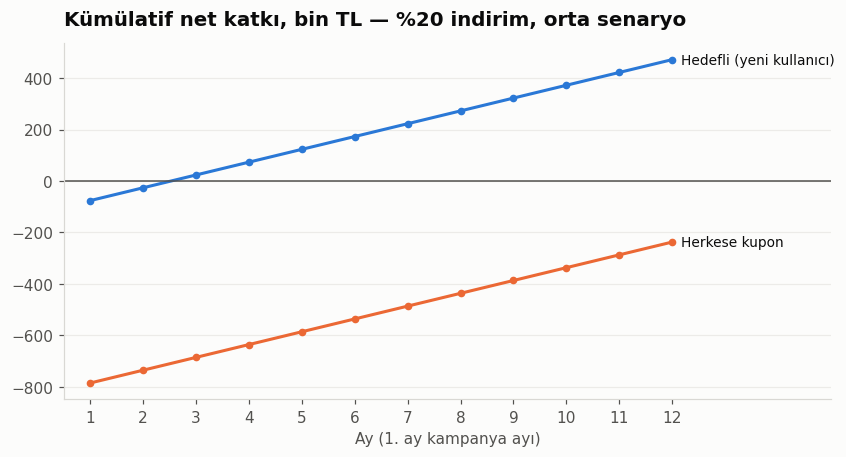

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.2))
for hedefli, renk, etiket in [(True, MAVI, "Hedefli (yeni kullanıcı)"), (False, TURUNCU, "Herkese kupon")]:
    s = simule(0.20, "orta", hedefli)
    ax.plot(s["ay"], s["kumulatif"] / 1000, color=renk, marker="o", markersize=4)
    ax.annotate(etiket, (s["ay"].iloc[-1], s["kumulatif"].iloc[-1] / 1000), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color=YAZI)
ax.axhline(0, color=YAZI_IKINCIL, linewidth=1)
ax.set_xticks(range(1, 13))
ax.set_xlim(0.5, 15)
ax.set_xlabel("Ay (1. ay kampanya ayı)")
ax.set_title("Kümülatif net katkı, bin TL — %20 indirim, orta senaryo")
kaydet(fig, "04_kupon_kumulatif")

## 5. Hangi indirim oranı, hangi senaryoda kendini amorti ediyor?

In [6]:
tablo = ozet[ozet["strateji"] == "Hedefli"].pivot(index="indirim", columns="senaryo", values="amorti_ayi")
tablo = tablo[["kötümser", "orta", "iyimser"]]
tablo.style.format(lambda v: "amorti olmuyor" if pd.isna(v) else f"{v:.0f}. ay") \
     .set_caption("Hedefli kupon: kümülatif net katkının pozitife döndüğü ay (12 ay içinde)")

senaryo,kötümser,orta,iyimser
indirim,,,
%10,6. ay,1. ay,1. ay
%20,10. ay,3. ay,2. ay
%30,amorti olmuyor,5. ay,3. ay


## Sonuç

Sonuçlar varsayımlara bağlı olsa da **yön** açık:

1. **Herkese kupon vermek** zaten kullanan müşterilere de indirim verdiği için (yamyamlaşma) 9 senaryonun 6'sında 12 ay sonunda
   hâlâ zarar ettiriyor; sadece iyimser senaryoda kâra geçiyor.
2. **Hedefli kupon** (sadece yeni kullanıcıya, zirve saatte, hedef ilçede) orta senaryoda %10 indirimle 1., %20 ile 3. ayda kendini amorti ediyor.
3. Daha yüksek indirim 12 ayda daha fazla toplam katkı getiriyor ama amorti süresi uzuyor ve kötümser senaryoda %30 indirim zararda kalıyor.
   Risk/getiri dengesi **%10–20** bandında.
4. Sonucu en çok değiştiren iki varsayım **fiyat esnekliği** ve **kalıcılık**. Bu ikisi gerçek bir **A/B testiyle** ölçülmeli
   → bir sonraki notebook.